In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import matplotlib.pyplot as plt
from SynOmics.metrics.narrow_utility.predictive_model_comp import compare_cross_validation
import warnings

# Cách 1: Bỏ qua tất cả các loại cảnh báo
warnings.filterwarnings("ignore")

# Coloring (violin/survival)
DATASET_COLORS = {
    "Original": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

def addColumns(data):
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])
    data["PD_Responders"] = "SD/MR"
    data.loc[responderCrit,"PD_Responders"] = 'Responder'
    data.loc[progressorCrit,"PD_Responders"] = 'Progressor'
    data["PD_nonPD"] = 0
    data.loc[progressorCrit, "PD_nonPD"] = 1
    import math
    for col in ["nonsyn_muts","clonal_muts","subclonal_muts","total_neoantigens"]:
        data[f"log_{col}"] = [math.log((x if x>=0 else 0)+1e-9,10) for x in data[col]]
    return data

def GenRegDF(df, categVars, quantVars, outcome=None):
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome]+quantVars]
    else:
        regDF = df[quantVars]
    nullQuants = []
    for q in quantVars:
        regDF.loc[:, q] = pd.to_numeric(regDF[q], errors='coerce')
        if regDF[q].isnull().sum()>0: nullQuants.append(q)
        med = regDF[q].median()
        regDF[q+"_upper"] = (regDF[q] > med).astype(int)
        regDF[q+"_lower"] = (regDF[q] <= med).astype(int)
    for c in categVars:
        dummies = pd.get_dummies(df[c], prefix=c)
        regDF = regDF.merge(dummies.iloc[:,1:], left_index=True, right_index=True)
    scaler = MinMaxScaler((0,1))
    good = [c for c in regDF.columns if c not in nullQuants]
    temp = pd.DataFrame(scaler.fit_transform(regDF[good]), index=regDF.index, columns=good)
    temp[nullQuants] = regDF[nullQuants]
    regDF = temp
    regDF["intercept"] = 1
    return regDF

def build_full_processed(dataset_dict):
    out = {}
    for name, df in dataset_dict.items():
        dfp = addColumns(df.copy())
        dfp["LN_Met"] = dfp["LN_Met"].astype(int)
        out[name] = dfp
    return out

def make_reg_tables(processed):
    fullProcessedData = {}
    for name, fullDF in processed.items():
        quantVars = ['log_nonsyn_muts','heterogeneity','purity','ploidy','Tx_Start_LDH']
        categVars = ['LN_Met']
        postIpi = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index
        noIpi   = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index
        prog = list(fullDF[fullDF['PD_Responders']=="Progressor"].index)
        nprog= list(fullDF[fullDF['PD_nonPD']==0].index)
        PDpost = list(set(postIpi)&set(prog)); nPDpost = [x for x in postIpi if x not in prog]
        PDno   = list(set(noIpi)&set(prog));  nPDno   = [x for x in noIpi if x not in prog]

        regDFs = {}
        for outcome, (g1, g0) in {
            "Ipi_Exp": [PDpost, nPDpost],
            "Ipi_Naive": [PDno, nPDno],
        }.items():
            tmp = fullDF.copy()
            tmp.loc[[i for i in g1 if i in tmp.index], 'outcome'] = 1
            tmp.loc[[i for i in g0 if i in tmp.index], 'outcome'] = 0
            tmp = tmp[~tmp['outcome'].isnull()]
            regDFs[outcome] = tmp

        fullRegDFs = {}
        for outcome in ["Ipi_Exp","Ipi_Naive"]:
            regDF = regDFs[outcome]
            tempDF = GenRegDF(fullDF[categVars+quantVars], categVars, quantVars)
            regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)
            regDF = regDF.select_dtypes(include=[np.number])
            regDF = regDF.loc[:, regDF.var()!=0]
            regDF['intercept'] = 1
            fullRegDFs[outcome] = regDF
            
        fullProcessedData[name] = fullRegDFs
    return fullProcessedData

In [2]:
seeds = [0, 1, 2, 3, 42]
Result_As_Seed = {}

for seed in seeds:
    all_methods = ['Origin', 'Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    dataset_dict = {}
    
    # 1. Load data
    for name in all_methods:
        dataset_filename = 'original_data' if name == 'Origin' else f"{name.lower().replace(' ', '')}_{seed}"
        try:
            data = pd.read_csv(f'../Melanoma/Data/{dataset_filename}.csv', index_col=0)
            ssgsea = pd.read_csv(f'../Melanoma/NarrowUtility/ssGSEA/MHC/{dataset_filename}.csv', index_col=0)
            dataset_dict[name] = pd.concat([data, ssgsea], axis=1)
        except FileNotFoundError:
            print(f"Skipping {name} for Seed {seed}: File not found.")
            continue

    if 'Origin' not in dataset_dict:
        print(f"Seed {seed} missing Origin data. Skipping entire seed.")
        continue


    try:
        processed = build_full_processed(dataset_dict)
        fullProcessedData = make_reg_tables(processed)
    except Exception as e:
        print(f"Error processing tables for Seed {seed}: {e}")
        continue
        
    case = 'Ipi_Exp'
    features = ['MHC-II', 'LN_Met_1', 'Tx_Start_LDH_lower', 'outcome']
    metric = 'roc_auc'
    
    models = {
        "Logistic_Regression": LogisticRegression(penalty='l2', max_iter=100000, random_state=42, solver='lbfgs', n_jobs=-1),
        'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
        "Multi-layer perceptrons": MLPClassifier(alpha=0.01, max_iter=10000, validation_fraction=0.1, random_state=42, hidden_layer_sizes=150),
    }
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    metric_results = {}

    
    try:
        ori = fullProcessedData['Origin'][case][features]
    except KeyError as e:
        print(f"Origin data for Seed {seed} missing required features {e}. Skipping seed.")
        continue

    for synth_name, data_case in fullProcessedData.items():
        if synth_name == "Origin":
            continue

        
        try:
            synth = data_case[case][features]
        except KeyError as e:
            print(f"Skipping {synth_name} at Seed {seed}: Missing column {e}")
            continue
        except Exception as e:
            print(f"Skipping {synth_name} at Seed {seed}: Unexpected error {e}")
            continue

        metric_results_cv = {}
        
        # 4. Duyệt qua từng Model trong Dataset đó
        for model_name, model in models.items():
            # --- TRY-EXCEPT CẤP ĐỘ MODEL ---
            try:
                mdl = clone(model)
    
                res = compare_cross_validation(
                    real=ori,
                    synth=synth,
                    target_col="outcome",
                    model=mdl,
                    cv=cv,
                    metric=metric,
                    n_jobs=-1,
                )
                
                metric_results_cv[model_name] = res
            except Exception as e:
                print(f"Error at Seed {seed} | Method {synth_name} | Model {model_name}: {e}")
                continue 
        

        if metric_results_cv:
            metric_results[synth_name] = metric_results_cv
                
    Result_As_Seed[seed] = metric_results

Error at Seed 1 | Method TVAE | Model Logistic_Regression: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0.0
Error at Seed 1 | Method TVAE | Model Random Forest: Got predict_proba of shape (7, 1), but need classifier with two classes.
Skipping TVAE at Seed 3: Missing column "['LN_Met_1'] not in index"


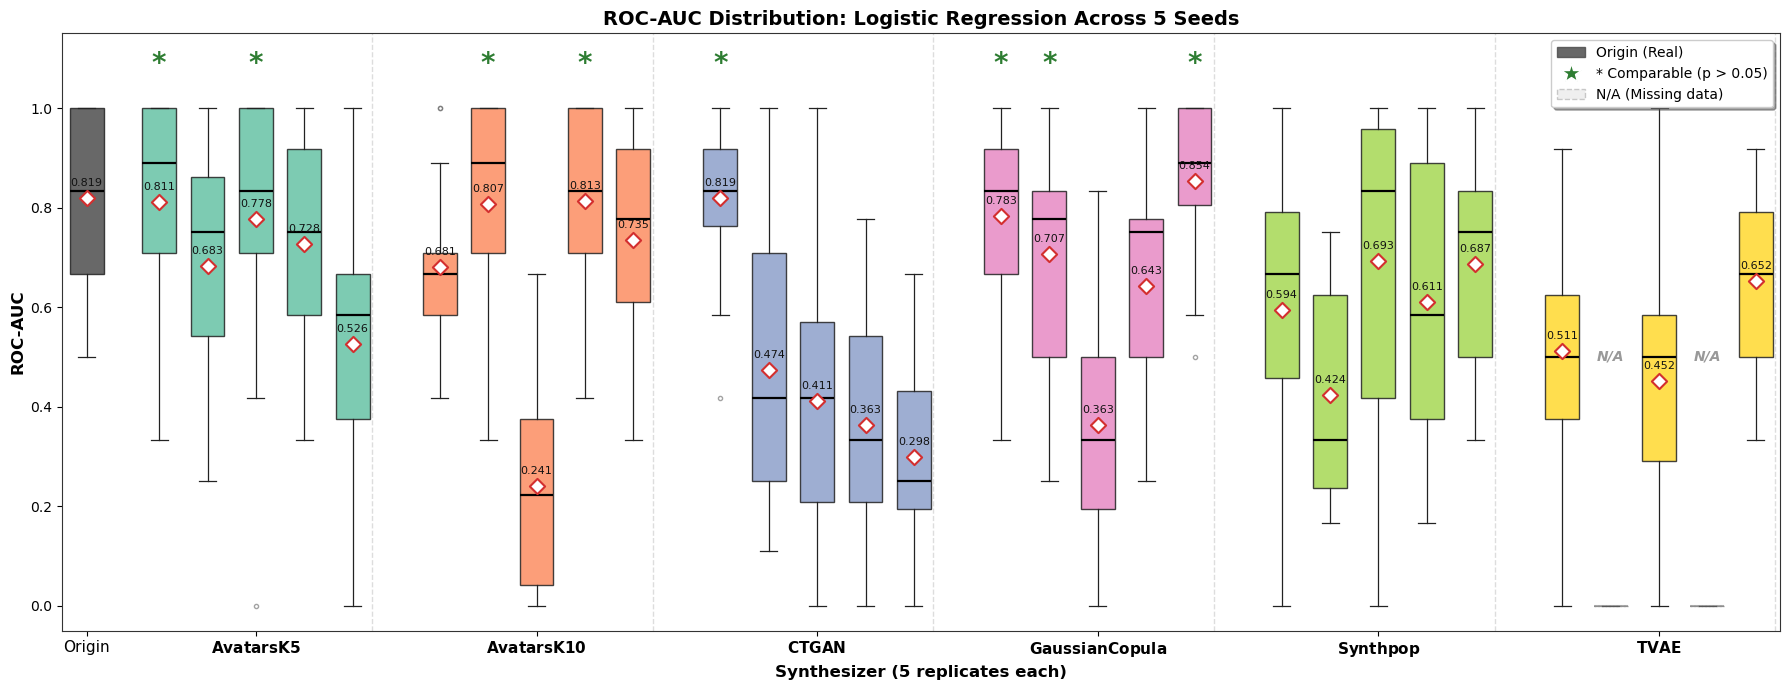

In [11]:
from visualize_predictive_modeling import plot_logistic_regression_replicates
synthesizer_names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

plot_logistic_regression_replicates(
    Result_As_Seed=Result_As_Seed,
    synthesizer_names=synthesizer_names,
    metric_name="ROC-AUC",
    classifier_name="Logistic_Regression",
    p_value_key="p_value",
    significance_threshold=0.05,
    save_path="PredictiveModeling/Figure6d_logistic_regresson.pdf",
    figsize=(18, 7),
    all_seeds=seeds  
)

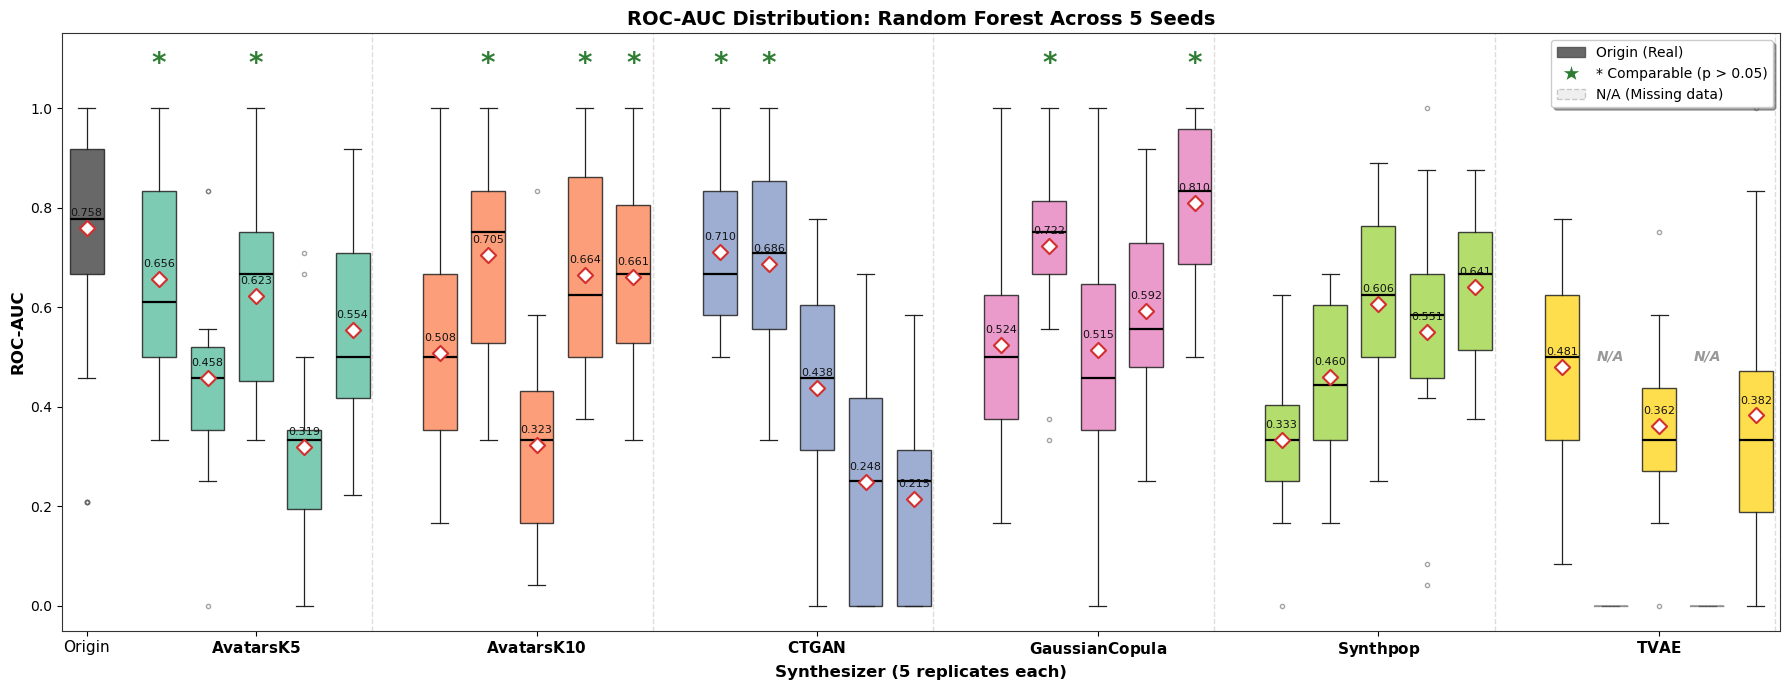

In [12]:
plot_logistic_regression_replicates(
    Result_As_Seed=Result_As_Seed,
    synthesizer_names=synthesizer_names,
    metric_name="ROC-AUC",
    classifier_name="Random Forest",
    p_value_key="p_value",
    significance_threshold=0.05,
    save_path="PredictiveModeling/RandomForest.png",
    figsize=(18, 7),
    all_seeds=seeds  
)

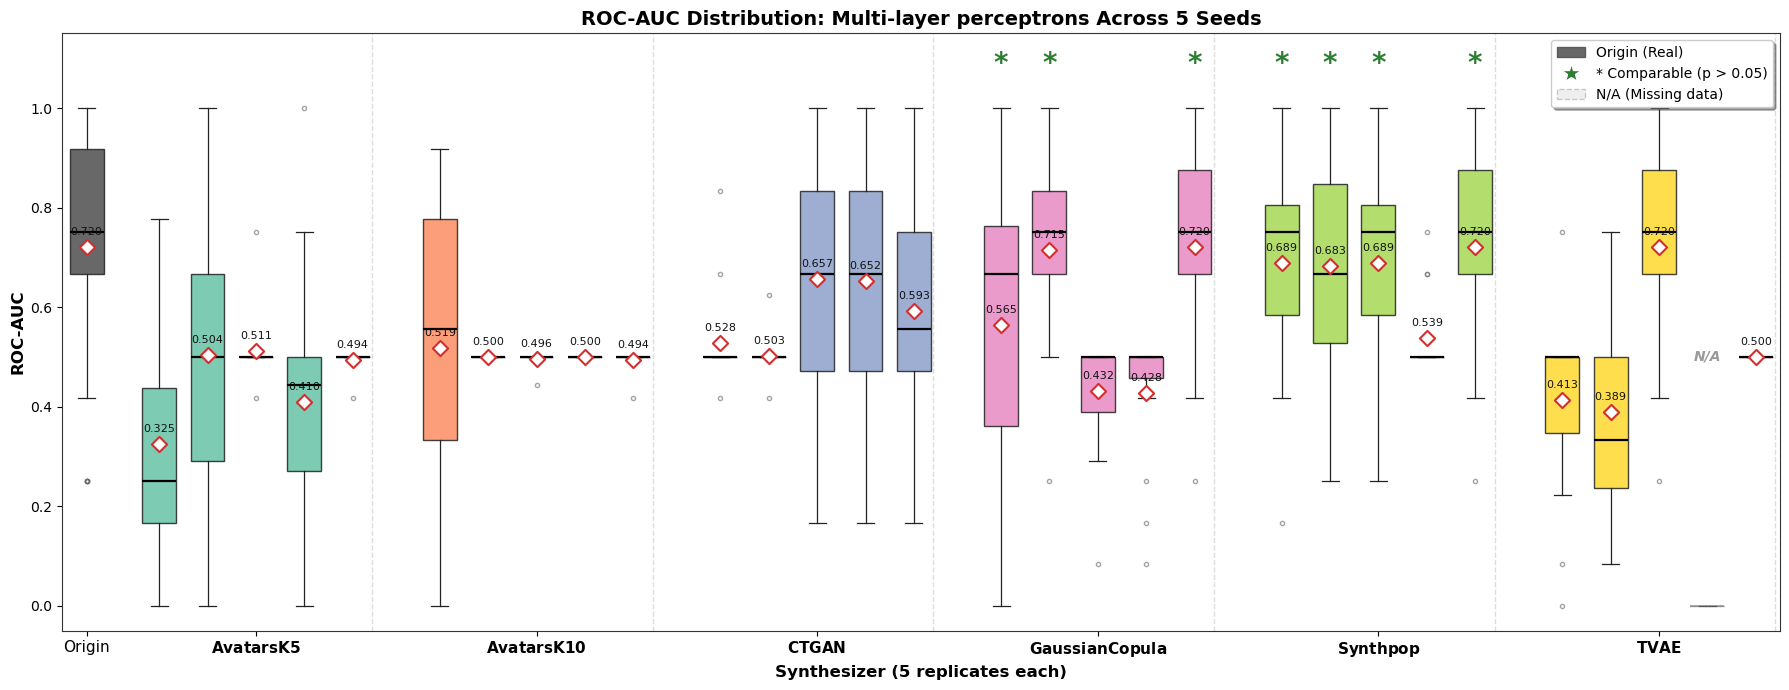

In [13]:
plot_logistic_regression_replicates(
    Result_As_Seed=Result_As_Seed,
    synthesizer_names=synthesizer_names,
    metric_name="ROC-AUC",
    classifier_name="Multi-layer perceptrons",
    p_value_key="p_value",
    significance_threshold=0.05,
    save_path="PredictiveModeling/MLP.png",
    figsize=(18, 7),
    all_seeds=seeds  
)

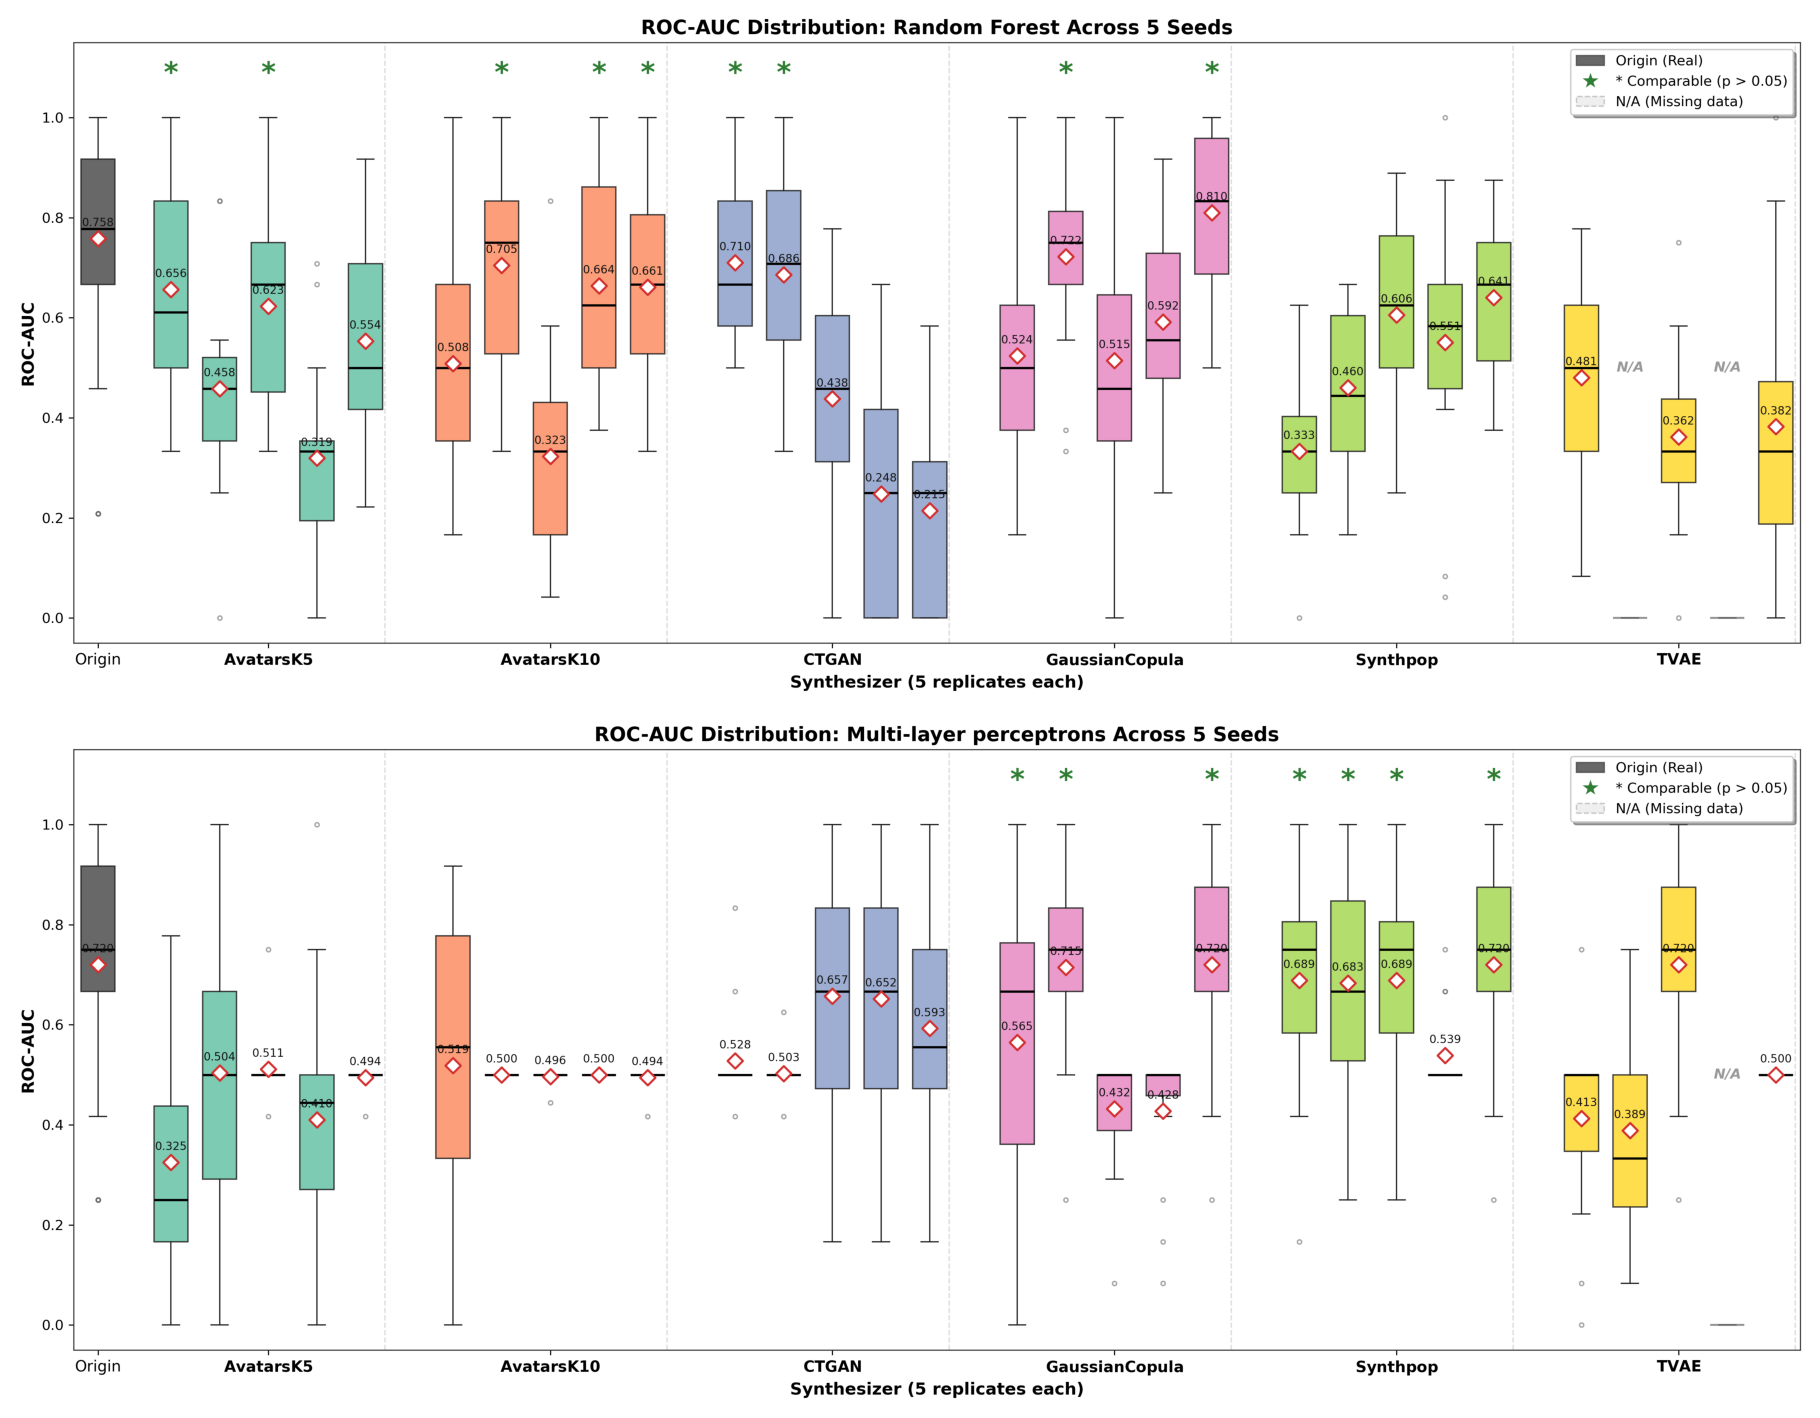

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import gridspec

image_paths = [
    'PredictiveModeling/RandomForest.png',
    'PredictiveModeling/MLP.png'
]

fig = plt.figure(figsize=(18, 14))

gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.02)

def show_img(ax, path):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")

for i, path in enumerate(image_paths):
    ax = fig.add_subplot(gs[i, 0])
    show_img(ax, path)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

combined_path = 'PredictiveModeling/Combined_MLP_RF.png'
fig.savefig(combined_path, dpi=300, bbox_inches='tight')

plt.show()